In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/exploring-coffee-sales-with-eda-and-visualization/Coffe_sales.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/kaggle/input/exploring-coffee-sales-with-eda-and-visualization/Coffe_sales.csv")
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [6]:
# Shape
print("Shape:", df.shape)

# Info
print(df.info())

# Missing values
print(df.isnull().sum())

# Summary statistics (numeric)
print(df.describe())

Shape: (3547, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB
None
hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64
       hour_of_day        money  Weekdaysort    Monthsort
co

In [7]:
# Fill missing numeric values with mean (if any)
df['money'] = df['money'].fillna(df['money'].mean())

# Fill missing categorical values with mode
df['coffee_name'] = df['coffee_name'].fillna(df['coffee_name'].mode()[0])
df['cash_type'] = df['cash_type'].fillna(df['cash_type'].mode()[0])
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
total_sales = df['money'].sum()
print("Total Sales:", total_sales)
avg_transaction = df['money'].mean()
print("Average Transaction Amount:", avg_transaction)
sales_by_coffee = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
print("Sales by Coffee Type:\n", sales_by_coffee)
sales_by_payment = df.groupby('cash_type')['money'].sum()
print("Sales by Payment Method:\n", sales_by_payment)
avg_sales_by_hour = df.groupby('hour_of_day')['money'].mean()
print("Average Sales by Hour:\n", avg_sales_by_hour)
sales_by_weekday = df.groupby('Weekday')['money'].sum()
sales_by_month = df.groupby('Month_name')['money'].sum()
print("Sales by Weekday:\n", sales_by_weekday)
print("Sales by Month:\n", sales_by_month)


Total Sales: 112245.58
Average Transaction Amount: 31.645215675218495
Sales by Coffee Type:
 coffee_name
Latte                  26875.30
Americano with Milk    24751.12
Cappuccino             17439.14
Americano              14650.26
Hot Chocolate           9933.46
Cocoa                   8521.16
Cortado                 7384.86
Espresso                2690.28
Name: money, dtype: float64
Sales by Payment Method:
 cash_type
card    112245.58
Name: money, dtype: float64
Average Sales by Hour:
 hour_of_day
6     29.880000
7     32.341136
8     29.863319
9     30.017686
10    31.093049
11    29.869611
12    30.786805
13    31.238933
14    31.883556
15    31.678051
16    32.488633
17    32.319662
18    32.855963
19    33.851354
20    33.011361
21    32.809949
22    32.169558
Name: money, dtype: float64
Sales by Weekday:
 Weekday
Fri    16802.66
Mon    17363.10
Sat    14733.52
Sun    13336.06
Thu    16091.40
Tue    18168.38
Wed    15750.46
Name: money, dtype: float64
Sales by Month:
 Month_nam

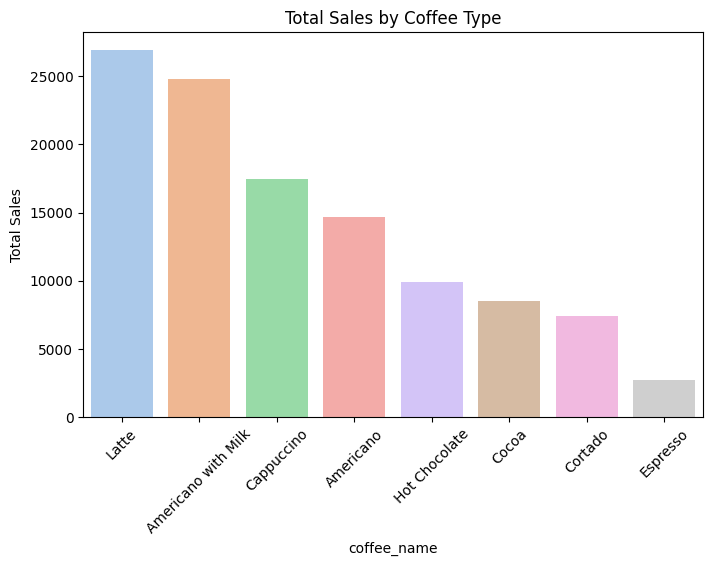

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_coffee.index, y=sales_by_coffee.values, palette='pastel')
plt.title("Total Sales by Coffee Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

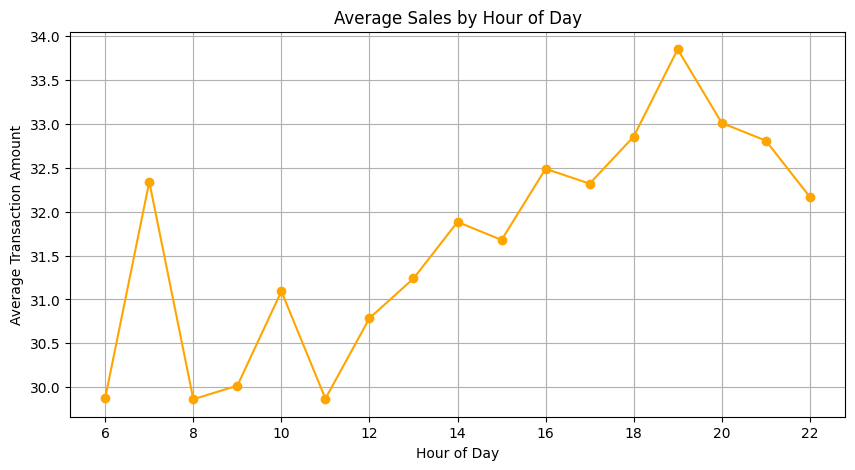

In [10]:
plt.figure(figsize=(10,5))
plt.plot(avg_sales_by_hour.index, avg_sales_by_hour.values, marker='o', color='orange')
plt.title("Average Sales by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Transaction Amount")
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


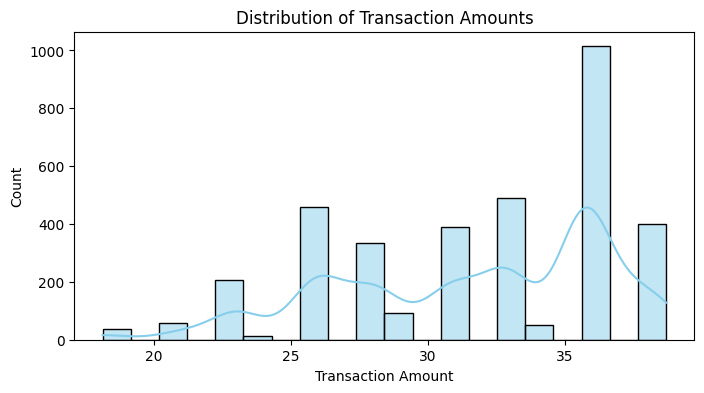

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df['money'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.show()

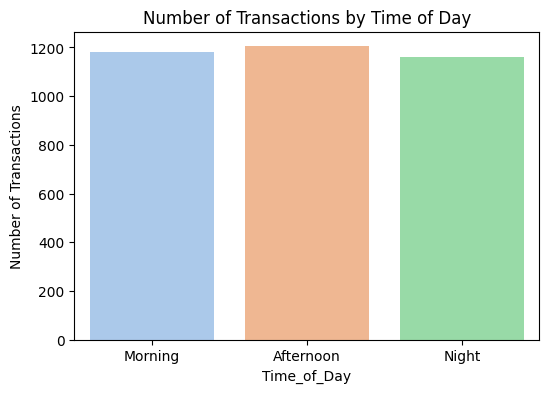

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Time_of_Day', data=df, palette='pastel')
plt.title("Number of Transactions by Time of Day")
plt.ylabel("Number of Transactions")
plt.show()

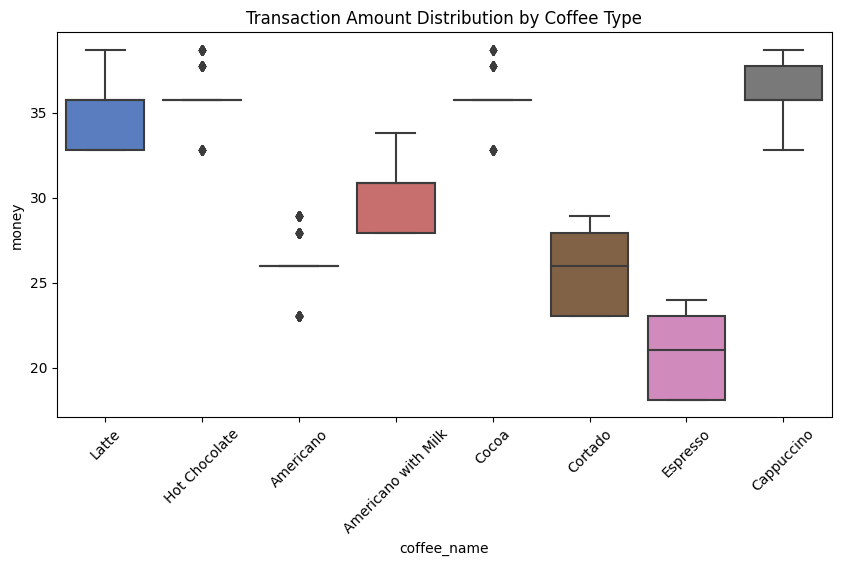

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x='coffee_name', y='money', data=df, palette='muted')
plt.title("Transaction Amount Distribution by Coffee Type")
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

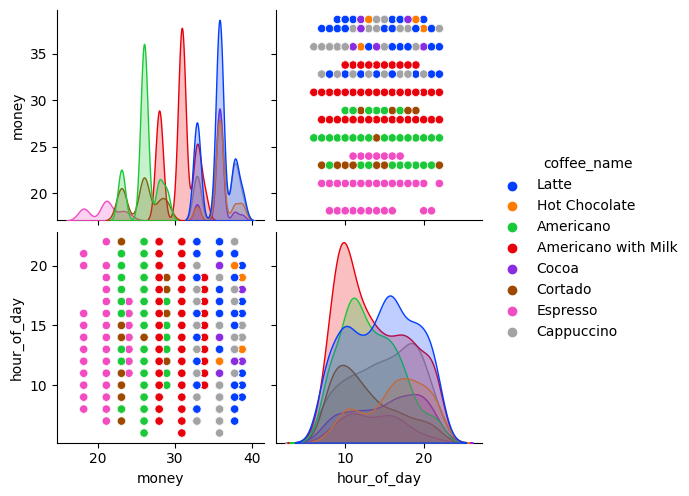

In [14]:
numeric_cols = ['money', 'hour_of_day']

# Pairplot with hue by coffee type
sns.pairplot(df[numeric_cols + ['coffee_name']], hue='coffee_name', palette='bright')
plt.show()

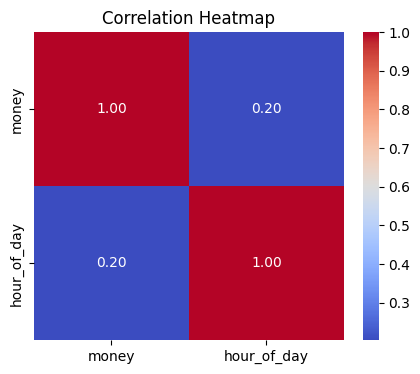

In [15]:
numeric_cols = ['money', 'hour_of_day']
corr = df[numeric_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# EDA

       hour_of_day        money  Weekdaysort    Monthsort
count  3547.000000  3547.000000  3547.000000  3547.000000
mean     14.185791    31.645216     3.845785     6.453905
std       4.234010     4.877754     1.971501     3.500754
min       6.000000    18.120000     1.000000     1.000000
25%      10.000000    27.920000     2.000000     3.000000
50%      14.000000    32.820000     4.000000     7.000000
75%      18.000000    35.760000     6.000000    10.000000
max      22.000000    38.700000     7.000000    12.000000


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


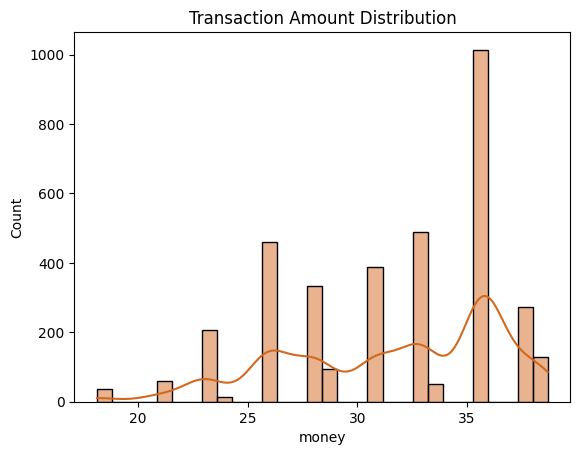

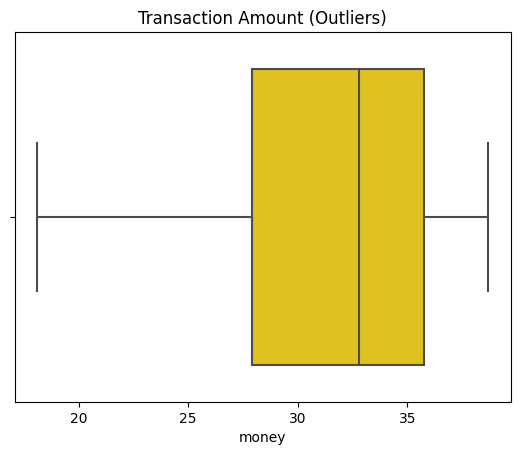

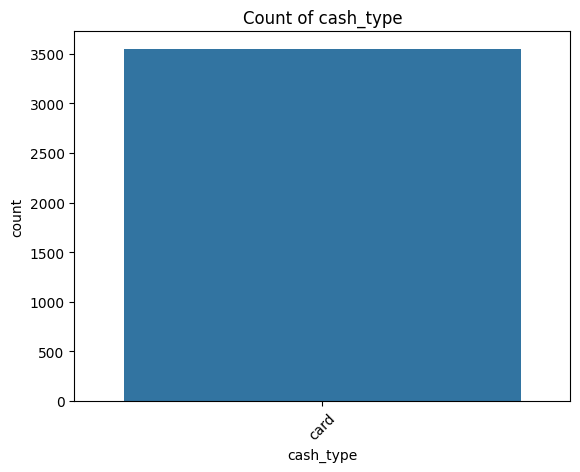

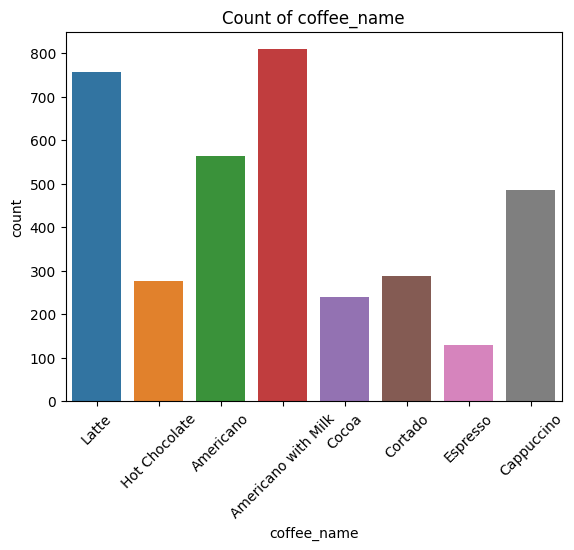

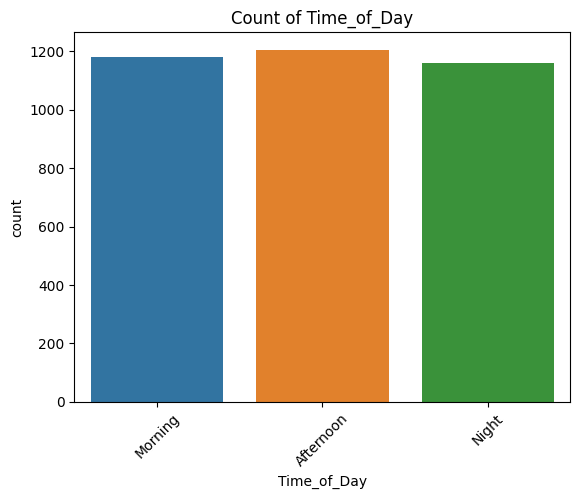

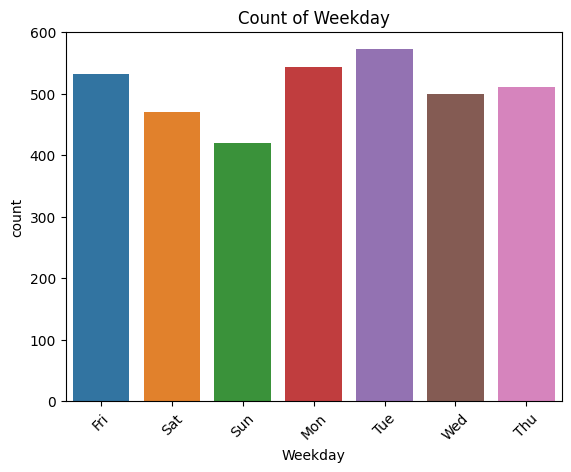

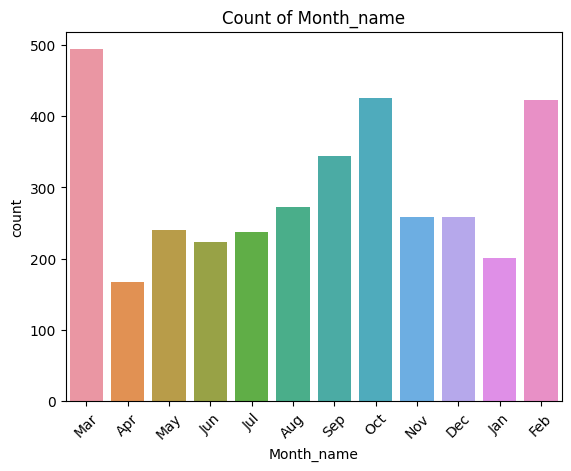

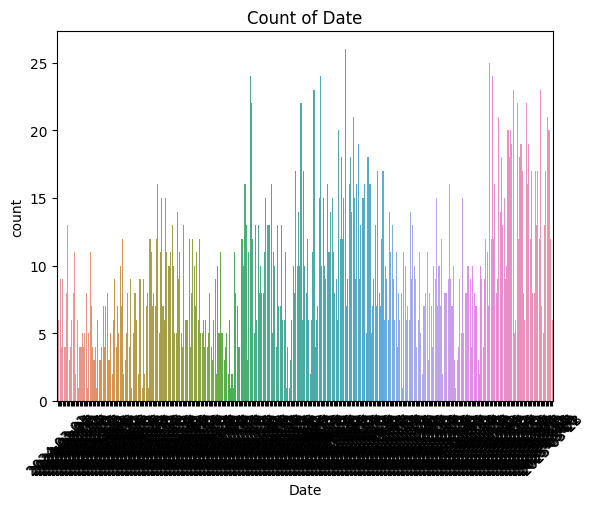

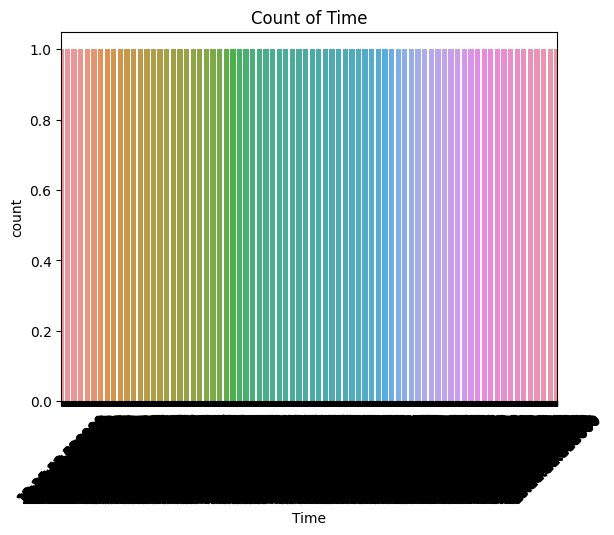

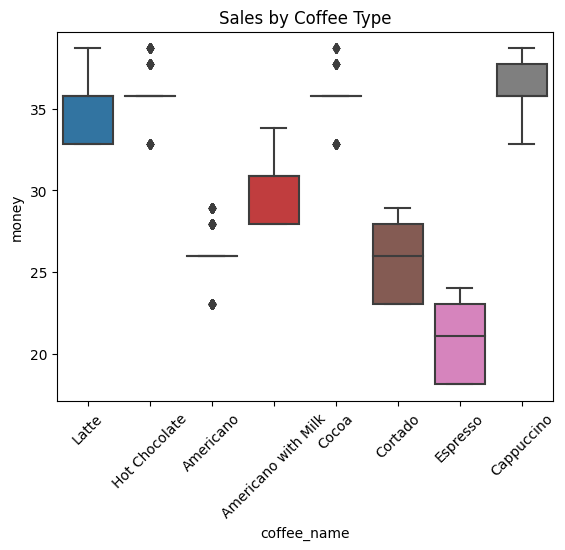

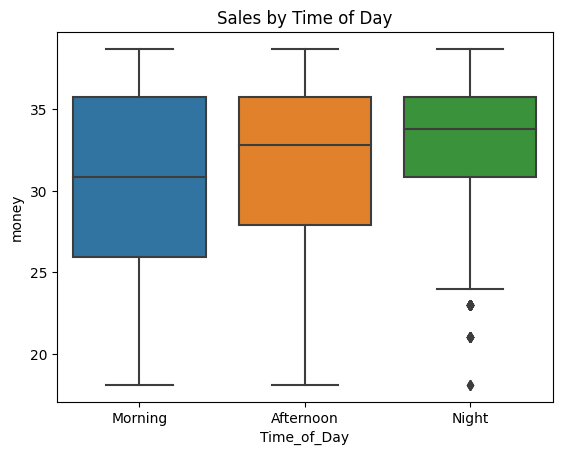

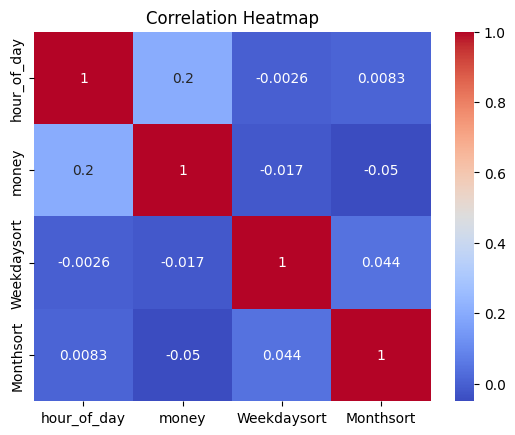

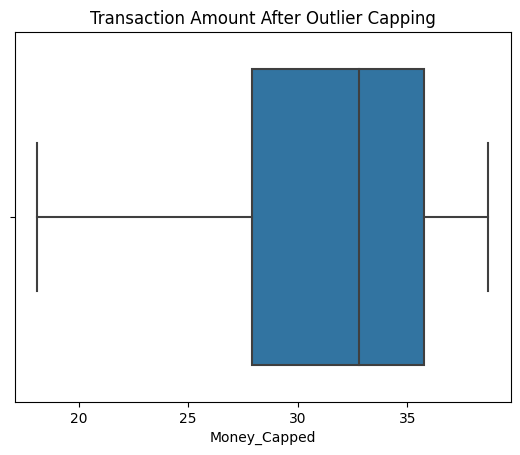

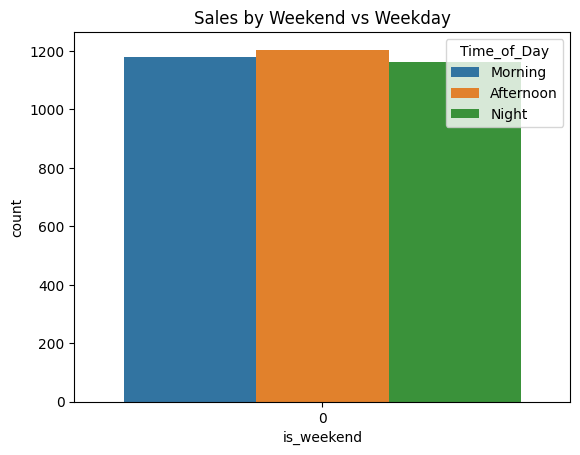

In [18]:
import pandas as pd
df = pd.read_csv("/kaggle/input/exploring-coffee-sales-with-eda-and-visualization/Coffe_sales.csv")

# Univariate - Numeric
num_cols = df.select_dtypes(include=['float64','int64']).columns
print(df[num_cols].describe())

sns.histplot(df['money'], bins=30, kde=True, color='chocolate')
plt.title("Transaction Amount Distribution")
plt.show()

sns.boxplot(x=df['money'], color='gold')
plt.title("Transaction Amount (Outliers)")
plt.show()

# Univariate - Categorical
cat_cols = df.select_dtypes('object').columns
for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()

# Bivariate
sns.boxplot(x='coffee_name', y='money', data=df)
plt.title("Sales by Coffee Type")
plt.xticks(rotation=45)
plt.show()

sns.boxplot(x='Time_of_Day', y='money', data=df)
plt.title("Sales by Time of Day")
plt.show()

# Correlation
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Outliers
Q1 = df['money'].quantile(0.25)
Q3 = df['money'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
df['Money_Capped'] = df['money'].clip(lower, upper)
sns.boxplot(x=df['Money_Capped'])
plt.title("Transaction Amount After Outlier Capping")
plt.show()

# Feature Engineering
df['is_weekend'] = df['Weekday'].isin(['Saturday','Sunday']).astype(int)
sns.countplot(x='is_weekend', hue='Time_of_Day', data=df)
plt.title("Sales by Weekend vs Weekday")
plt.show()

df.to_csv("Coffee_Sales_Cleaned.csv", index=False)

In [19]:
df.isnull().sum()

hour_of_day     0
cash_type       0
money           0
coffee_name     0
Time_of_Day     0
Weekday         0
Month_name      0
Weekdaysort     0
Monthsort       0
Date            0
Time            0
Money_Capped    0
is_weekend      0
dtype: int64


hour_of_day int64 Discrete Numeric

cash_type object Nominal Categorical

money float64 Continuous Numeric

coffee_name object Nominal Categorical

Time_of_Day object Ordinal Categorical (Morning < Noon < Evening < Night)

Weekday object Ordinal Categorical (Mon < Tue < …)

Month_name object Ordinal Categorical (Jan < Feb < …)

Weekdaysort int64 Ordinal Numeric (Encoded)

Monthsort int64 Ordinal Numeric (Encoded)

Date object Date/TimeTime object Date/Time

In [21]:
cat_cols = ["cash_type","coffee_name","Time_of_Day","Weekday","Month_name"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
num_cols = ["hour_of_day","money","Weekdaysort","Monthsort"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [23]:
df["Date"] = df["Date"].fillna(df["Date"].mode()[0])
df["Time"] = df["Time"].fillna(df["Time"].mode()[0])

In [24]:
cash = pd.get_dummies(df["cash_type"], dtype=int, prefix='cash', drop_first=True)
df = pd.concat([df, cash], axis=1).drop(['cash_type'], axis=1)

In [25]:
coffee = pd.get_dummies(df["coffee_name"], dtype=int, prefix='coffee', drop_first=True)
df = pd.concat([df, coffee], axis=1).drop(['coffee_name'], axis=1)

In [27]:
weekday = pd.get_dummies(df["Weekday"], dtype=int, prefix='wd', drop_first=True)
df = pd.concat([df, weekday], axis=1).drop(['Weekday'], axis=1)

In [28]:
month = pd.get_dummies(df["Month_name"], dtype=int, prefix='mon', drop_first=True)
df = pd.concat([df, month], axis=1).drop(['Month_name'], axis=1)

In [30]:
df

,hour_of_day,money,Weekdaysort,Monthsort,Date,Time,Money_Capped,is_weekend,coffee_Americano with Milk,coffee_Cappuccino,...,mon_Jan,mon_Jul,mon_Jun,mon_Mar,mon_May,mon_Nov,mon_Oct,mon_Sep,day,hour
0,10,38.70,5,3,2024-03-01,2025-12-04 10:15:50.520,38.70,0,0,0,...,0,0,0,1,0,0,0,0,1,10
1,12,38.70,5,3,2024-03-01,2025-12-04 12:19:22.539,38.70,0,0,0,...,0,0,0,1,0,0,0,0,1,12
2,12,38.70,5,3,2024-03-01,2025-12-04 12:20:18.089,38.70,0,0,0,...,0,0,0,1,0,0,0,0,1,12
3,13,28.90,5,3,2024-03-01,2025-12-04 13:46:33.006,28.90,0,0,0,...,0,0,0,1,0,0,0,0,1,13
4,13,38.70,5,3,2024-03-01,2025-12-04 13:48:14.626,38.70,0,0,0,...,0,0,0,1,0,0,0,0,1,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3542,10,35.76,7,3,2025-03-23,2025-12-04 10:34:54.894,35.76,0,0,1,...,0,0,0,1,0,0,0,0,23,10
3543,14,35.76,7,3,2025-03-23,2025-12-04 14:43:37.362,35.76,0,0,0,...,0,0,0,1,0,0,0,0,23,14
3544,14,35.76,7,3,2025-03-23,2025-12-04 14:44:16.864,35.76,0,0,0,...,0,0,0,1,0,0,0,0,23,14
3545,15,25.96,7,3,2025-03-23,2025-12-04 15:47:28.723,25.96,0,0,0,...,0,0,0,1,0,0,0,0,23,15
